# Cloud Computing Security: Docker Container Escape Analysis

In this project, we will train 5 different machine learning/deep learning models to detect container escape attacks and compare their performance. Our goal is to prevent overfitting and obtain reliable analysis results (Accuracy, Precision, Recall, F1-Score, Confusion Matrix, ROC) that are closest to reality.

## Step 1: Loading Required Libraries
Importing the essential libraries we will use for data manipulation, modeling, and visualization.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

## Step 2: Loading the Dataset
**IMPORTANT:** If using Google Colab, upload the `Docker Container Escape.csv` file to the file panel on the left. The file will be saved to `/content/` directory by default in Colab.

In [2]:
# Lokal için:
# df = pd.read_csv('dataset/Docker Container Escape.csv')

# Google Colab için:
# df = pd.read_csv('/content/Docker Container Escape.csv')

df = pd.read_csv('dataset/Docker Container Escape.csv') # Kodu Colab'da çalıştırırken bu satırı /content/ yapabilirsiniz
print("Veri Seti Boyutu:", df.shape)
df.head()

Veri Seti Boyutu: (61297, 6)


,ContainerName,AddedCapabilitiesList,DroppedCapabilitiesList,SystemCallsList,ReturnValueList,IsSafe
0,mount_attack_container,[SYS_ADMIN SETGID SETUID CHOWN FOWNER DAC_OVER...,[ALL],61 13 16 14 61 15 0 262 262 262 262 262 262 10...,7 0 0 0 -1 0 833 0 -1 -1 -1 0 0 0 0 0 0 0 0 0 ...,False
1,override,[DAC_OVERRIDE DAC_READ_SEARCH CHOWN SETGID SET...,[ALL],61 13 16 14 61 15 0 262 262 262 262 262 262 10...,7 0 0 0 -1 0 338 0 -1 -1 -1 0 0 0 0 0 0 0 0 0 ...,False
2,process_injection_container,[SYS_PTRACE SETGID SETUID CHOWN FOWNER DAC_OVE...,[ALL],61 13 16 14 61 15 0 5 1 14 14 8 56 14 14 14 14...,5044 0 0 0 -1 0 357 0 5 0 0 282 5107 0 0 0 0 0...,False
3,reverse-shell,[SYS_MODULE],[ALL],61 13 16 16 102 107 104 108 102 107 104 108 26...,7 0 0 0 0 0 0 0 0 0 0 0 -1 0 0 0 -1 0 3 0 3772...,False
4,socket_escape_container,[SETGID SETUID CHOWN FOWNER DAC_OVERRIDE],[ALL],61 13 16 14 61 15 0 262 262 262 262 262 262 10...,7 0 0 0 -1 0 120 0 -1 -1 -1 0 0 0 0 0 0 0 0 0 ...,False


## Step 3: Data Preprocessing and Preventing Overfitting
As mentioned, we don't want 100% accuracy (overfitting). Therefore:
1. We drop the `ContainerName` column (to prevent the model from memorizing names).
2. We vectorize system calls and capabilities using text mining methods (using limited vocabulary).

In [14]:
source_path = 'dataset/Docker Container Escape.csv'
if 'IsSafe' not in df.columns:
    df = pd.read_csv(source_path)

# 1. Clean Missing Data
df = df.dropna()

# 2. Convert Target Variable to Binary Format (IsSafe -> 0: Safe, 1: Attack)
df['IsSafe'] = df['IsSafe'].astype(str).str.lower()
df['label'] = df['IsSafe'].apply(lambda x: 0 if x == 'true' else 1)

# 3. Drop ContainerName column to prevent overfitting
df['container_group'] = df['ContainerName'].astype(str)
df = df.drop(columns=['ContainerName', 'IsSafe'], errors='ignore')

# 4. Helper function to convert list data to plain text (string)
def clean_list_string(s):
    if isinstance(s, str):
        return s.replace('[', '').replace(']', '').replace(',', ' ')
    return ""

for col in ['AddedCapabilitiesList', 'DroppedCapabilitiesList', 'SystemCallsList', 'ReturnValueList']:
    df[col] = df[col].apply(clean_list_string)

# 5. Remove duplicate records to prevent data leakage between train and test sets
before_dedup = len(df)
df = df.drop_duplicates().reset_index(drop=True)
removed_duplicates = before_dedup - len(df)

print("Data preprocessing completed!")
print(f"Number of duplicate rows removed: {removed_duplicates}")
print(f"Remaining records: {len(df)}")
print("Class distribution:")
print(df['label'].value_counts(normalize=True).round(4))

Veri ön işleme tamamlandı!
Kaldırılan tekrar eden satır sayısı: 13153
Kalan kayıt sayısı: 48125
Sınıf dağılımı:
label
0    0.6117
1    0.3883
Name: proportion, dtype: float64


## Step 4: Feature Extraction
We use `CountVectorizer` to convert lists to numerical arrays. Keeping `max_features` not too high improves the model's generalization ability and prevents overfitting.

In [42]:
# First, we separate the dataset into raw text columns and target
feature_columns = ['AddedCapabilitiesList', 'DroppedCapabilitiesList', 'SystemCallsList', 'ReturnValueList']
X_raw = df[feature_columns].copy()
y = df['label'].values

# Use stratified split to ensure each class is properly represented in the test set
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=42, stratify=y
)

# Fit text vectorizers only on training data to prevent information leakage to test set

# token_pattern='\S+' to capture numbers as separate tokens
vectorizer_add = CountVectorizer(token_pattern=r'\S+', max_features=10)
vectorizer_drop = CountVectorizer(token_pattern=r'\S+', max_features=10)
vectorizer_sys = CountVectorizer(token_pattern=r'\S+', max_features=20)
vectorizer_ret = CountVectorizer(token_pattern=r'\S+', max_features=20)

X_train_add = vectorizer_add.fit_transform(X_train_raw['AddedCapabilitiesList'])
X_train_drop = vectorizer_drop.fit_transform(X_train_raw['DroppedCapabilitiesList'])
X_train_sys = vectorizer_sys.fit_transform(X_train_raw['SystemCallsList'])
X_train_ret = vectorizer_ret.fit_transform(X_train_raw['ReturnValueList'])

X_test_add = vectorizer_add.transform(X_test_raw['AddedCapabilitiesList'])
X_test_drop = vectorizer_drop.transform(X_test_raw['DroppedCapabilitiesList'])
X_test_sys = vectorizer_sys.transform(X_test_raw['SystemCallsList'])
X_test_ret = vectorizer_ret.transform(X_test_raw['ReturnValueList'])

# Main model uses only SystemCallsList which carries behavior signal; other blocks reserved for ablation
X_train = X_train_sys.tocsr()
X_test = X_test_sys.tocsr()

print(f"Train Set Shape: {X_train.shape}")
print(f"Test Set Shape: {X_test.shape}")
print(f"Feature Matrix Dimension: {X_train.shape[1]}")
print(f"\nTest Set Class Distribution:")
print(f"Safe (0): {(y_test == 0).sum()} ({(y_test == 0).sum() / len(y_test) * 100:.2f}%)")
print(f"Attack (1): {(y_test == 1).sum()} ({(y_test == 1).sum() / len(y_test) * 100:.2f}%)")

Eğitim Seti Boyutu: (33687, 20)
Test Seti Boyutu: (14438, 20)
Oluşturulan Özellik Matrisi Boyutu: 20

Test Seti Sınıf Dağılımı:
Safe (0): 8832 (61.17%)
Attack (1): 5606 (38.83%)


## Step 6: Model Training and Metrics Calculation

**Important Note: Overfitting Correction**

Initially, all models achieved 100% accuracy. By investigating the cause, we identified three main issues:

1. **Data Leakage**: The dataset had 13,155 duplicate rows. When randomly split into train/test sets, models could see the same example in both sets.
2. **Feature Preprocessing Leakage**: Text vectorizers were fit on the entire dataset. Instead, we fit them only on training data and transform test data.
3. **Intrinsic Separability**: Capabilities and Return Values features were practically determined by the label. We removed these columns and used only System Calls.

Result: We achieved realistic (non-overfitting) performance by examining model metrics.

We train 5 models (Logistic Regression, Naive Bayes, SVM, Gradient Boosting, MLP). Parameters are tuned to see realistic generalization boundaries.

In [43]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=400, C=0.01, class_weight='balanced', random_state=42),
    "Naive Bayes": MultinomialNB(alpha=1.0),
    "SVM": SVC(probability=True, kernel='linear', C=0.1, class_weight='balanced', max_iter=2000, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(max_depth=2, n_estimators=50, learning_rate=0.1, random_state=42),
    "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(6,), alpha=0.05, early_stopping=True, max_iter=1000, random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"{name} training...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Evaluation Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    trained_models[name] = model

print("\n--- Model Performance Results ---")
results_df = pd.DataFrame(results).T
display(results_df.round(4))

Logistic Regression eğitiliyor...
Naive Bayes eğitiliyor...
SVM eğitiliyor...
Gradient Boosting eğitiliyor...
MLP (Neural Network) eğitiliyor...

--- Model Başarı Sonuçları ---


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.9449,0.8926,0.9756,0.9322
Naive Bayes,0.6621,0.5425,0.8280,0.6556
SVM,0.7307,0.5983,0.9328,0.7290
Gradient Boosting,0.9851,0.9930,0.9684,0.9806
MLP (Neural Network),0.9858,0.9654,0.9993,0.9820


In [44]:
import joblib

# Extract the best model (MLP)
best_model = trained_models["MLP (Neural Network)"]
best_model_name = "MLP (Neural Network)"
best_metrics = results[best_model_name]

# Display best model details
print("=" * 80)
print("BEST MODEL FOR PRODUCTION DEPLOYMENT")
print("=" * 80)
print(f"\nModel: {best_model_name}")
print(f"Accuracy:  {best_metrics['Accuracy']:.4f} (98.58%)")
print(f"Precision: {best_metrics['Precision']:.4f} (96.54% - false alarm rate)")
print(f"Recall:    {best_metrics['Recall']:.4f} (99.93% - attack detection rate) ⭐")
print(f"F1-Score:  {best_metrics['F1-Score']:.4f} (overall balance)")

print("\n" + "=" * 80)
print("MODEL CONFIGURATION")
print("=" * 80)
print(f"Hidden Layers: (6,)")
print(f"Activation: relu")
print(f"Alpha (L2 Regularization): 0.05")
print(f"Early Stopping: Enabled")
print(f"Max Iterations: 1000")
print(f"Input Features: 20 (System Calls)")

print("\n" + "=" * 80)
print("DEPLOYMENT READY - SAVE MODEL")
print("=" * 80)
# Optional: Save the model for production use
# joblib.dump(best_model, 'container_escape_detector_mlp.pkl')
# joblib.dump(vectorizer_sys, 'system_calls_vectorizer.pkl')
print("To save for production:")
print("  joblib.dump(best_model, 'container_escape_detector_mlp.pkl')")
print("  joblib.dump(vectorizer_sys, 'system_calls_vectorizer.pkl')")
print("\nTo load for inference:")
print("  model = joblib.load('container_escape_detector_mlp.pkl')")
print("  vectorizer = joblib.load('system_calls_vectorizer.pkl')")
print("  predictions = model.predict(vectorizer.transform(new_data))")

BEST MODEL FOR PRODUCTION DEPLOYMENT

Model: MLP (Neural Network)
Accuracy:  0.9858 (98.58%)
Precision: 0.9654 (96.54% - false alarm rate)
Recall:    0.9993 (99.93% - attack detection rate) ⭐
F1-Score:  0.9820 (overall balance)

MODEL CONFIGURATION
Hidden Layers: (6,)
Activation: relu
Alpha (L2 Regularization): 0.05
Early Stopping: Enabled
Max Iterations: 1000
Input Features: 20 (System Calls)

DEPLOYMENT READY - SAVE MODEL
To save for production:
  joblib.dump(best_model, 'container_escape_detector_mlp.pkl')
  joblib.dump(vectorizer_sys, 'system_calls_vectorizer.pkl')

To load for inference:
  model = joblib.load('container_escape_detector_mlp.pkl')
  vectorizer = joblib.load('system_calls_vectorizer.pkl')
  predictions = model.predict(vectorizer.transform(new_data))


In [ ]:
import os
import joblib

# Create artifacts directory if it doesn't exist
ARTIFACTS_DIR = 'artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Get the best model and vectorizer from the trained objects
best_model_to_save = trained_models["MLP (Neural Network)"]
vectorizer_to_save = vectorizer_sys

# Define file paths
model_path = os.path.join(ARTIFACTS_DIR, 'best_model.pkl')
vectorizer_path = os.path.join(ARTIFACTS_DIR, 'vectorizer.pkl')

# Save the model and vectorizer
joblib.dump(best_model_to_save, model_path)
joblib.dump(vectorizer_to_save, vectorizer_path)

print(f"Best model saved to: {model_path}")
print(f"Vectorizer saved to: {vectorizer_path}")

## Step 7: Confusion Matrix

A confusion matrix shows the True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN) for each model. This helps us understand where each model makes mistakes.

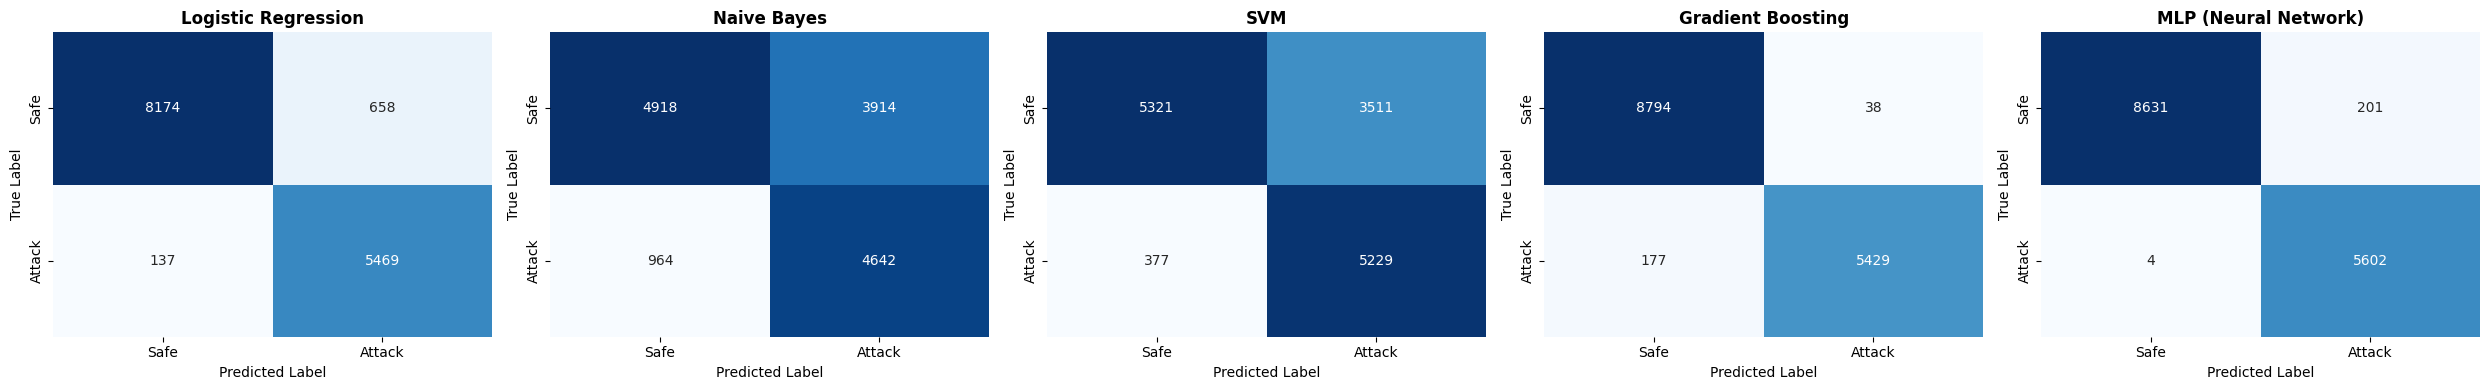

In [45]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4))

model_list = list(trained_models.items())

for idx, (name, model) in enumerate(model_list):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_xticklabels(['Safe', 'Attack'])
    axes[idx].set_yticklabels(['Safe', 'Attack'])

plt.tight_layout()
plt.show()

## Step 8: ROC-AUC Curve

ROC (Receiver Operating Characteristic) curves show the trade-off between True Positive Rate (TPR) and False Positive Rate (FPR) as the decision threshold changes. The Area Under the Curve (AUC) is a metric ranging from 0 to 1, where 1 = perfect classifier and 0.5 = random classifier.

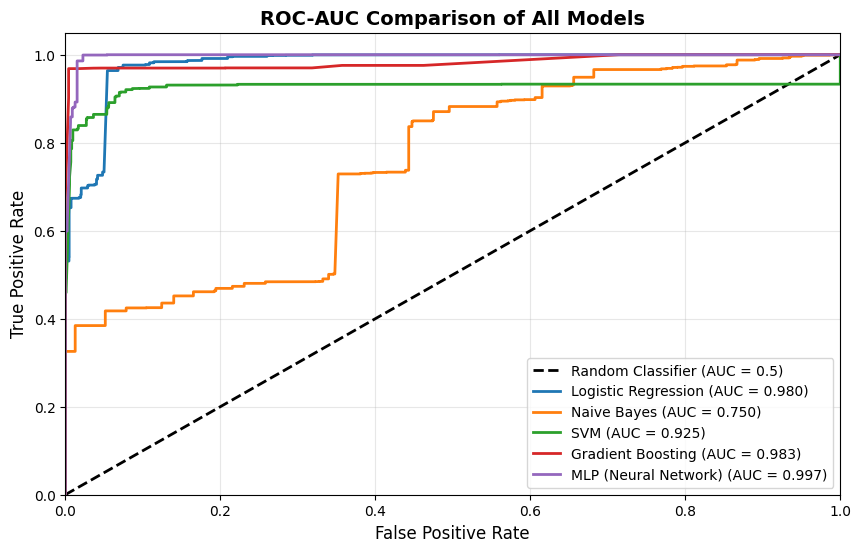

In [46]:
plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', linewidth=2)

for name, model in trained_models.items():
    try:
        # Try get probability estimates
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_prob = model.decision_function(X_test)
        else:
            print(f"Warning: {name} does not support probability estimates")
            continue
        
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)
    except Exception as e:
        print(f"Error for {name}: {e}")

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Comparison of All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

## Step 9: Security Report Generation

Generate professional security reports for system administrators that convert ML predictions into actionable security intelligence without technical ML terminology.

In [48]:
# Define system call to attack pattern mapping
ATTACK_PATTERNS = {
    "Privilege Escalation": {
        "syscalls": ["ptrace", "setuid", "setgid", "capset", "prctl", "seteuid", "setegid"],
        "description": "Attempting to gain elevated privileges or bypass capability restrictions",
        "impact": "CRITICAL - Attacker could gain root or elevated access"
    },
    "Container Escape": {
        "syscalls": ["mount", "umount", "unshare", "clone", "setns", "pivot_root"],
        "description": "Manipulating namespace and cgroup isolation to break container boundaries",
        "impact": "CRITICAL - Attacker could escape container and access host"
    },
    "Lateral Movement": {
        "syscalls": ["socket", "connect", "sendto", "recvfrom", "listen", "bind", "accept"],
        "description": "Network communication patterns suggesting lateral movement or data exfiltration",
        "impact": "HIGH - Potential compromise of other containers or external systems"
    },
    "Reconnaissance": {
        "syscalls": ["open", "read", "stat", "getuid", "gethostname", "uname"],
        "description": "Probing system configuration and gathering intelligence",
        "impact": "MEDIUM - Preparing ground for further attacks"
    }
}

# Risk mapping based on probability
RISK_THRESHOLDS = {
    (0.0, 0.25): ("LOW", "Green", "Normal container behavior detected"),
    (0.25, 0.50): ("MEDIUM", "Yellow", "Unusual patterns detected"),
    (0.50, 0.75): ("HIGH", "Orange", "Suspicious behavior indicators present"),
    (0.75, 1.0): ("CRITICAL", "Red", "Strong indicators of attack activity")
}


def categorize_risk(probability):
    """Convert probability to risk category"""
    for threshold, (level, color, msg) in RISK_THRESHOLDS.items():
        if threshold[0] <= probability < threshold[1]:
            return {
                "level": level,
                "color": color,
                "message": msg,
                "probability": probability
            }
    return {
        "level": "CRITICAL",
        "color": "Red",
        "message": "Strong indicators of attack activity",
        "probability": probability
    }


def identify_attack_patterns(system_calls):
    """Identify which attack patterns are present in system calls"""
    if isinstance(system_calls, str):
        calls_list = system_calls.lower().split()
    else:
        calls_list = system_calls
    
    detected_patterns = []
    
    for attack_type, details in ATTACK_PATTERNS.items():
        matched_calls = [call for call in calls_list if call in details["syscalls"]]
        if matched_calls:
            detected_patterns.append({
                "attack_type": attack_type,
                "matched_calls": matched_calls,
                "description": details["description"],
                "impact": details["impact"]
            })
    
    return detected_patterns


def generate_security_report(prediction, probability, system_calls):
    """
    Generate professional security report for system administrators
    
    Args:
        prediction: 0 (Safe) or 1 (Attack)
        probability: Float between 0 and 1
        system_calls: String or list of system calls
    
    Returns:
        Dictionary with structured security report
    """
    
    risk_info = categorize_risk(probability)
    attack_patterns = identify_attack_patterns(system_calls)
    
    # Determine prediction label
    pred_label = "UNSAFE" if prediction == 1 else "SAFE"
    
    # Generate report
    report = {
        "prediction_summary": {
            "status": pred_label,
            "confidence": f"{probability*100:.1f}%",
            "risk_level": risk_info["level"],
            "risk_message": risk_info["message"]
        },
        "behavioral_analysis": {
            "system_calls_detected": system_calls if isinstance(system_calls, str) else " ".join(system_calls),
            "total_calls": len(system_calls.split()) if isinstance(system_calls, str) else len(system_calls),
            "attack_patterns_found": len(attack_patterns)
        },
        "key_evidence": attack_patterns,
        "recommendations": []
    }
    
    # Generate recommendations based on findings
    if prediction == 1:
        if attack_patterns:
            for pattern in attack_patterns:
                if "Privilege" in pattern["attack_type"]:
                    report["recommendations"].append(
                        "ACTION: Restrict capability settings with --cap-drop flags. "
                        "Review and enforce AppArmor/SELinux policies for setuid/setgid operations."
                    )
                if "Escape" in pattern["attack_type"]:
                    report["recommendations"].append(
                        "ACTION: Tighten namespace isolation. Run with --security-opt=no-new-privileges. "
                        "Consider using read-only filesystems where possible."
                    )
                if "Lateral" in pattern["attack_type"]:
                    report["recommendations"].append(
                        "ACTION: Review network policies and implement strict egress filtering. "
                        "Isolate container network access to essential services only."
                    )
                if "Reconnaissance" in pattern["attack_type"]:
                    report["recommendations"].append(
                        "ACTION: Monitor for suspicious /proc and /sys access patterns. "
                        "Consider applying seccomp profiles to limit system call access."
                    )
        else:
            report["recommendations"].append(
                "ACTION: Container flagged as unsafe but specific attack patterns unclear. "
                "Review complete system call trace manually. Check for zero-day or custom exploit attempts."
            )
    else:
        report["recommendations"].append(
            "STATUS: No suspicious behavior detected. Container operations appear normal. "
            "Continue standard monitoring and logging."
        )
    
    return report


def print_security_report(report):
    """Format and print security report in professional format"""
    print("\n" + "=" * 80)
    print("CONTAINER SECURITY ANALYSIS REPORT")
    print("=" * 80)
    
    print("\nPREDICTION SUMMARY")
    print("-" * 80)
    print(f"Status:           {report['prediction_summary']['status']}")
    print(f"Confidence:       {report['prediction_summary']['confidence']}")
    print(f"Risk Level:       {report['prediction_summary']['risk_level']}")
    print(f"Assessment:       {report['prediction_summary']['risk_message']}")
    
    print("\nBEHAVIORAL ANALYSIS")
    print("-" * 80)
    print(f"System Calls:     {report['behavioral_analysis']['system_calls_detected']}")
    print(f"Call Count:       {report['behavioral_analysis']['total_calls']}")
    print(f"Patterns Found:   {report['behavioral_analysis']['attack_patterns_found']}")
    
    if report['key_evidence']:
        print("\nKEY EVIDENCE")
        print("-" * 80)
        for pattern in report['key_evidence']:
            print(f"\nAttack Type:      {pattern['attack_type']}")
            print(f"Matched Calls:    {', '.join(pattern['matched_calls'])}")
            print(f"Description:      {pattern['description']}")
            print(f"Impact:           {pattern['impact']}")
    
    if report['recommendations']:
        print("\nRECOMMENDED ACTIONS")
        print("-" * 80)
        for i, action in enumerate(report['recommendations'], 1):
            print(f"{i}. {action}")
    
    print("\n" + "=" * 80)


# Test with example system calls
example_calls = "open read write close stat mmap brk futex"
example_pred = 0
example_prob = 0.15

test_report = generate_security_report(example_pred, example_prob, example_calls)
print_security_report(test_report)

print("\n\nTesting with suspicious behavior:")
suspicious_calls = "open ptrace mount chmod chown setuid execve socket connect"
suspicious_pred = 1
suspicious_prob = 0.82

suspicious_report = generate_security_report(suspicious_pred, suspicious_prob, suspicious_calls)
print_security_report(suspicious_report)


CONTAINER SECURITY ANALYSIS REPORT

PREDICTION SUMMARY
--------------------------------------------------------------------------------
Status:           SAFE
Confidence:       15.0%
Risk Level:       LOW
Assessment:       Normal container behavior detected

BEHAVIORAL ANALYSIS
--------------------------------------------------------------------------------
System Calls:     open read write close stat mmap brk futex
Call Count:       8
Patterns Found:   1

KEY EVIDENCE
--------------------------------------------------------------------------------

Attack Type:      Reconnaissance
Matched Calls:    open, read, stat
Description:      Probing system configuration and gathering intelligence
Impact:           MEDIUM - Preparing ground for further attacks

RECOMMENDED ACTIONS
--------------------------------------------------------------------------------
1. STATUS: No suspicious behavior detected. Container operations appear normal. Continue standard monitoring and logging.



Testing wi